In [1]:
import numpy as np
import jax.numpy as jnp

from fbpinns.domains import RectangularDomainND
from fbpinns.problems import Problem
from fbpinns.decompositions import RectangularDecompositionND
from fbpinns.networks import FCN
from fbpinns.constants import Constants
from fbpinns.trainers import FBPINNTrainer

domain = RectangularDomainND

domain_init_kwargs = dict(
    xmin=np.array([0.,0.]),
    xmax=np.array([1.,1.]),
)

class HomogeneousLaplacian2D(Problem):

    @staticmethod
    def init_params(sigma=0.2):
    
        static_params = {
            "dims": (1, 2),
            "sigma": sigma,
        }
    
        return static_params, {}

    @staticmethod
    def sample_constraints(all_params, domain, key, sampler, batch_shapes):

        x_batch_phys = domain.sample_interior(all_params, key, sampler, batch_shapes[0])

        required_ujs_phys = (
            (0, ()),
            (0, (0, 0)),
            (0, (1, 1)),
        )

        return [[x_batch_phys, required_ujs_phys]]

    @staticmethod
    def loss_fn(all_params, constraints):

        x_batch, u, u_xx, u_yy = constraints[0]

        x = x_batch[:, 0:1]
        y = x_batch[:, 1:2]

        f = 32.0 * (x * (1.0 - x) + y * (1.0 - y))

        phys = jnp.mean((-u_xx - u_yy - f) ** 2)

        return phys

    @staticmethod
    def constraining_fn(all_params, x_batch, u):

        sigma = all_params["static"]["problem"]["sigma"]

        x = x_batch[:, 0:1]
        y = x_batch[:, 1:2]

        c = (
            jnp.tanh(x / sigma)
            * jnp.tanh((1.0 - x) / sigma)
            * jnp.tanh(y / sigma)
            * jnp.tanh((1.0 - y) / sigma)
        )

        return c * u

    @staticmethod
    def exact_solution(all_params, x_batch, batch_shape=None):

        x = x_batch[:, 0:1]
        y = x_batch[:, 1:2]

        return 16.0 * x * (1.0 - x) * y * (1.0 - y)


problem = HomogeneousLaplacian2D
problem_init_kwargs = dict(
    sigma=0.2,
)

def build_decomposition(levels, delta=1.9):

    xs = []
    ws = []

    for L in levels:

        if L == 1:
            centers = np.array([0.5])
            widths = np.array([delta])
        else:
            centers = np.linspace(0,1,L)
            widths = np.ones(L) * (delta/(L-1))

        xs.append(centers)
        ws.append(widths)

    xs_all = np.concatenate(xs)
    ws_all = np.concatenate(ws)

    return dict(
        subdomain_xs=[xs_all, xs_all],
        subdomain_ws=[ws_all, ws_all],
        unnorm=(0.0,1.0)
    )

[INFO] 2026-03-12 22:27:46 - <fbpinns.constants.Constants object at 0x000001D68D657770>
run: pinn_3x64
domain: <class 'fbpinns.domains.RectangularDomainND'>
domain_init_kwargs: {'xmin': array([0., 0.]), 'xmax': array([1., 1.])}
problem: <class '__main__.HomogeneousLaplacian2D'>
problem_init_kwargs: {'sigma': 0.2}
decomposition: <class 'fbpinns.decompositions.RectangularDecompositionND'>
decomposition_init_kwargs: {'subdomain_xs': [array([0.5]), array([0.5])], 'subdomain_ws': [array([2.]), array([2.])], 'unnorm': (0.0, 1.0)}
network: <class 'fbpinns.networks.FCN'>
network_init_kwargs: {'layer_sizes': [2, 64, 64, 64, 1]}
n_steps: 15000
scheduler: <class 'fbpinns.schedulers.AllActiveSchedulerND'>
scheduler_kwargs: {}
ns: ((80, 80),)
n_test: (350, 350)
sampler: grid
optimiser: <function adam at 0x000001D68D3FCE00>
optimiser_kwargs: {'learning_rate': 0.001}
seed: 0
summary_freq: 200
test_freq: 200
model_save_freq: 10000
show_figures: True
save_figures: False
clear_output: False
hostname: da

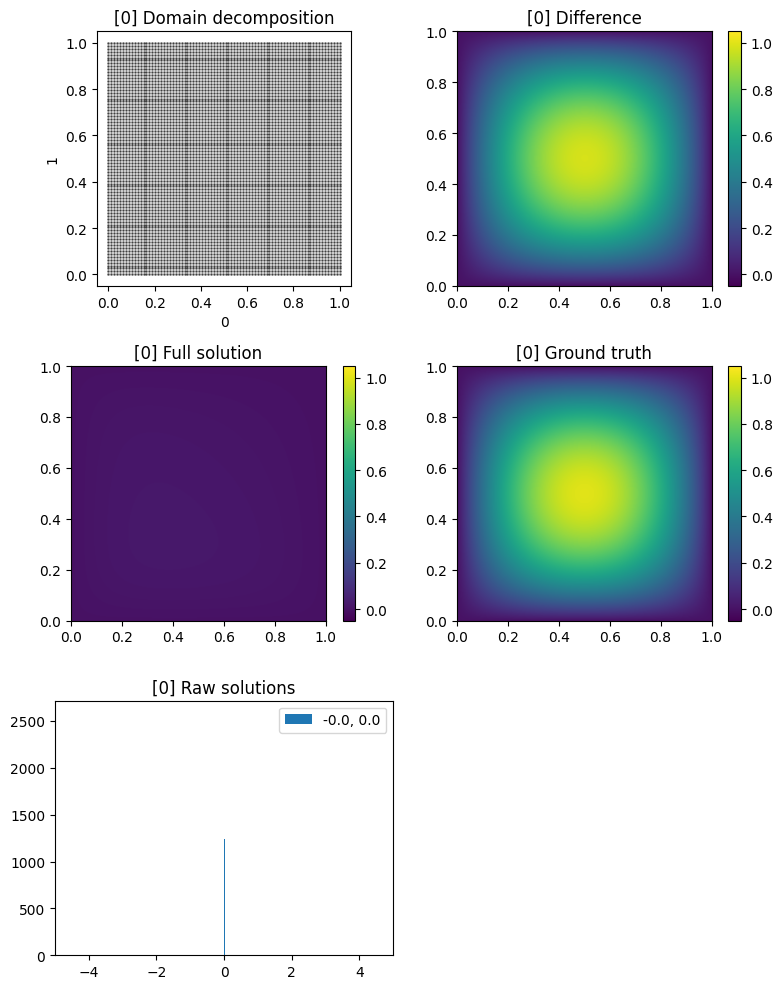

[INFO] 2026-03-12 22:28:49 - [i: 200/15000] loss: 17.0224 rate: 4.2 elapsed: 0.02 hr pinn_3x64
[INFO] 2026-03-12 22:29:42 - [i: 400/15000] loss: 0.7229 rate: 4.5 elapsed: 0.03 hr pinn_3x64
[INFO] 2026-03-12 22:30:35 - [i: 600/15000] loss: 0.0912 rate: 4.5 elapsed: 0.05 hr pinn_3x64
[INFO] 2026-03-12 22:31:32 - [i: 800/15000] loss: 0.0376 rate: 4.3 elapsed: 0.06 hr pinn_3x64
[INFO] 2026-03-12 22:32:26 - [i: 1000/15000] loss: 0.0226 rate: 4.4 elapsed: 0.08 hr pinn_3x64


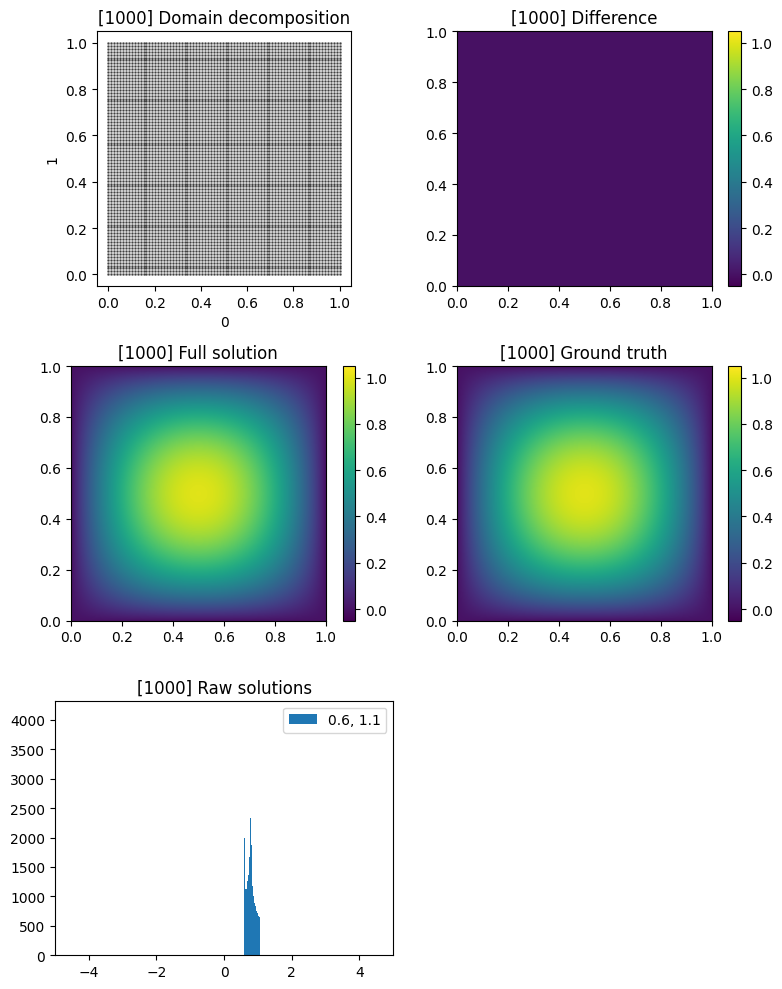

[INFO] 2026-03-12 22:33:18 - [i: 1200/15000] loss: 0.0156 rate: 4.8 elapsed: 0.09 hr pinn_3x64
[INFO] 2026-03-12 22:34:12 - [i: 1400/15000] loss: 0.0121 rate: 4.5 elapsed: 0.11 hr pinn_3x64
[INFO] 2026-03-12 22:35:07 - [i: 1600/15000] loss: 0.0099 rate: 4.3 elapsed: 0.12 hr pinn_3x64
[INFO] 2026-03-12 22:35:58 - [i: 1800/15000] loss: 0.0084 rate: 4.8 elapsed: 0.14 hr pinn_3x64
[INFO] 2026-03-12 22:36:51 - [i: 2000/15000] loss: 0.0073 rate: 4.5 elapsed: 0.15 hr pinn_3x64


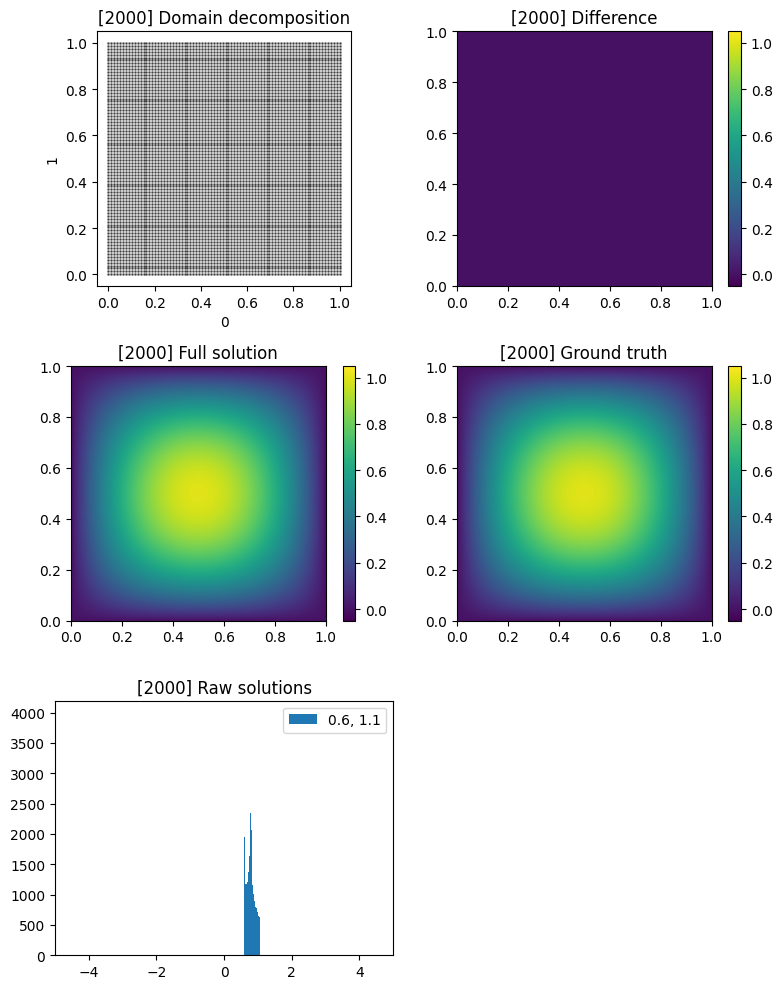

[INFO] 2026-03-12 22:37:46 - [i: 2200/15000] loss: 0.0063 rate: 4.5 elapsed: 0.17 hr pinn_3x64
[INFO] 2026-03-12 22:38:42 - [i: 2400/15000] loss: 0.0056 rate: 4.3 elapsed: 0.18 hr pinn_3x64
[INFO] 2026-03-12 22:39:33 - [i: 2600/15000] loss: 0.0050 rate: 4.8 elapsed: 0.20 hr pinn_3x64
[INFO] 2026-03-12 22:40:29 - [i: 2800/15000] loss: 0.0140 rate: 4.3 elapsed: 0.21 hr pinn_3x64
[INFO] 2026-03-12 22:41:21 - [i: 3000/15000] loss: 0.0041 rate: 4.6 elapsed: 0.23 hr pinn_3x64


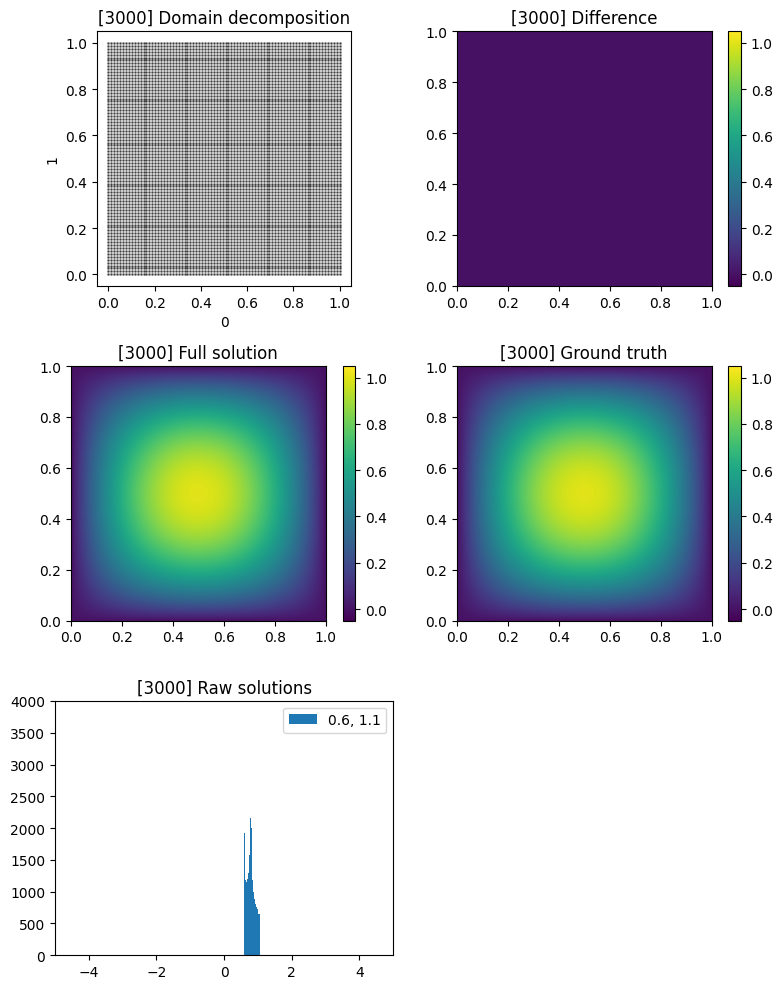

[INFO] 2026-03-12 22:42:15 - [i: 3200/15000] loss: 0.0037 rate: 4.5 elapsed: 0.24 hr pinn_3x64
[INFO] 2026-03-12 22:43:09 - [i: 3400/15000] loss: 0.0034 rate: 4.6 elapsed: 0.26 hr pinn_3x64
[INFO] 2026-03-12 22:44:04 - [i: 3600/15000] loss: 0.0044 rate: 4.3 elapsed: 0.27 hr pinn_3x64
[INFO] 2026-03-12 22:44:58 - [i: 3800/15000] loss: 0.0029 rate: 4.5 elapsed: 0.29 hr pinn_3x64
[INFO] 2026-03-12 22:45:49 - [i: 4000/15000] loss: 0.0050 rate: 4.7 elapsed: 0.30 hr pinn_3x64


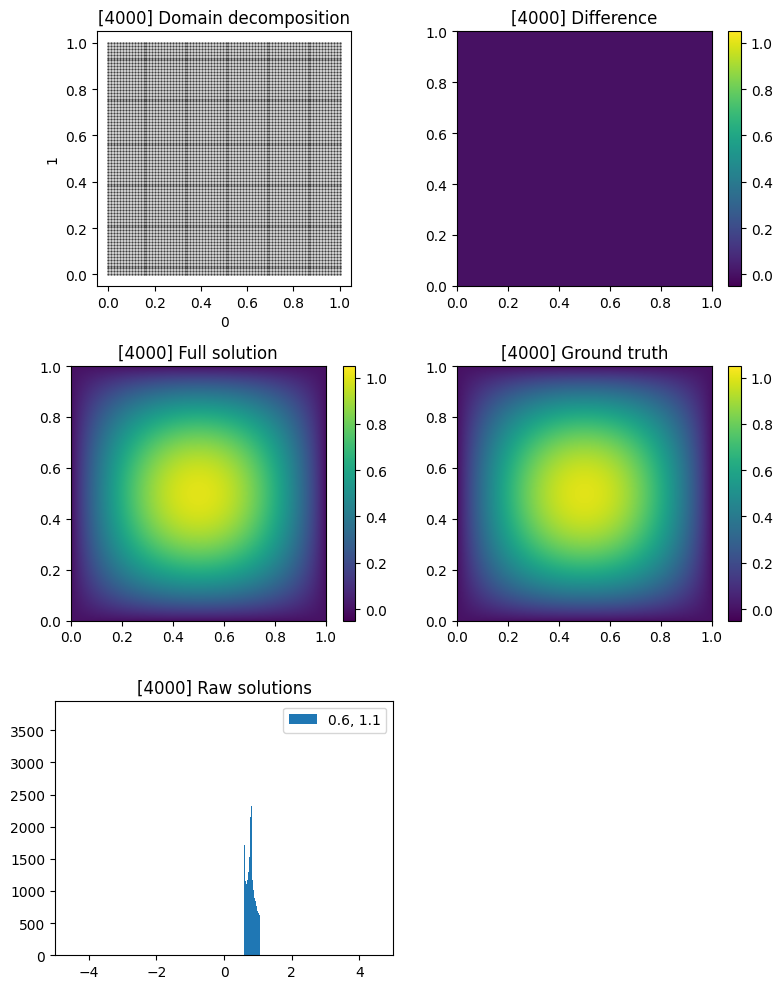

[INFO] 2026-03-12 22:46:44 - [i: 4200/15000] loss: 0.0025 rate: 4.5 elapsed: 0.32 hr pinn_3x64
[INFO] 2026-03-12 22:47:38 - [i: 4400/15000] loss: 0.0024 rate: 4.6 elapsed: 0.33 hr pinn_3x64
[INFO] 2026-03-12 22:48:31 - [i: 4600/15000] loss: 0.0025 rate: 4.5 elapsed: 0.34 hr pinn_3x64
[INFO] 2026-03-12 22:49:22 - [i: 4800/15000] loss: 0.0020 rate: 4.7 elapsed: 0.36 hr pinn_3x64
[INFO] 2026-03-12 22:50:13 - [i: 5000/15000] loss: 0.0019 rate: 4.7 elapsed: 0.37 hr pinn_3x64


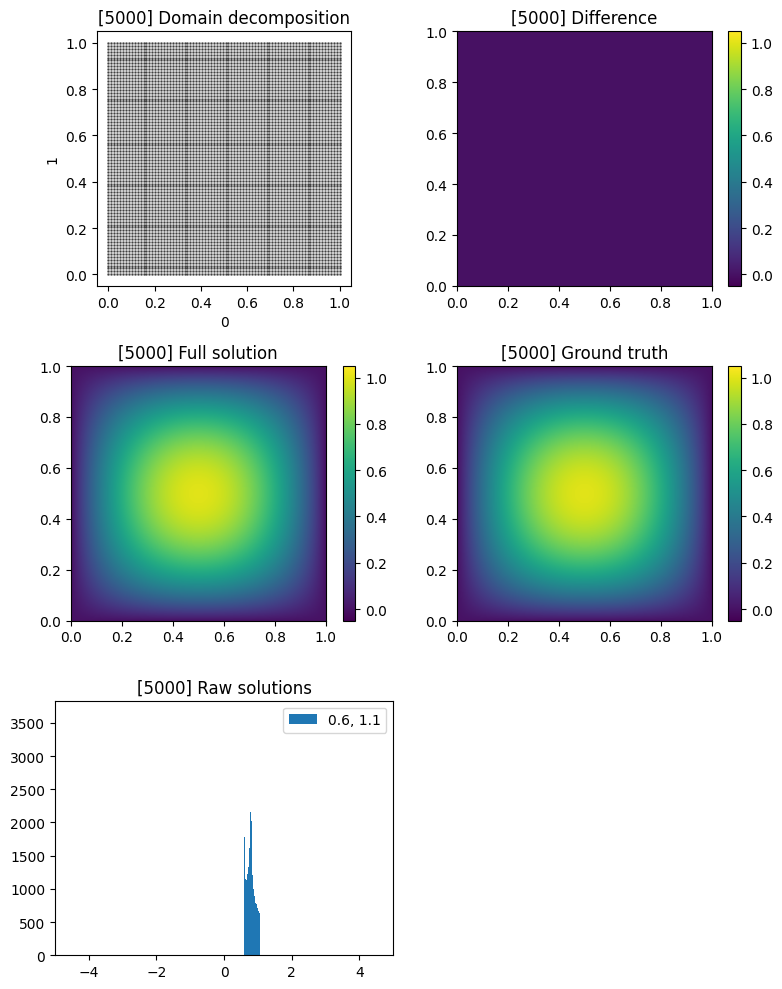

[INFO] 2026-03-12 22:51:07 - [i: 5200/15000] loss: 0.0853 rate: 4.5 elapsed: 0.39 hr pinn_3x64
[INFO] 2026-03-12 22:52:06 - [i: 5400/15000] loss: 0.0019 rate: 4.1 elapsed: 0.40 hr pinn_3x64
[INFO] 2026-03-12 22:53:01 - [i: 5600/15000] loss: 0.0053 rate: 4.3 elapsed: 0.42 hr pinn_3x64
[INFO] 2026-03-12 22:53:50 - [i: 5800/15000] loss: 0.0015 rate: 4.9 elapsed: 0.43 hr pinn_3x64
[INFO] 2026-03-12 22:54:49 - [i: 6000/15000] loss: 0.0049 rate: 4.1 elapsed: 0.45 hr pinn_3x64


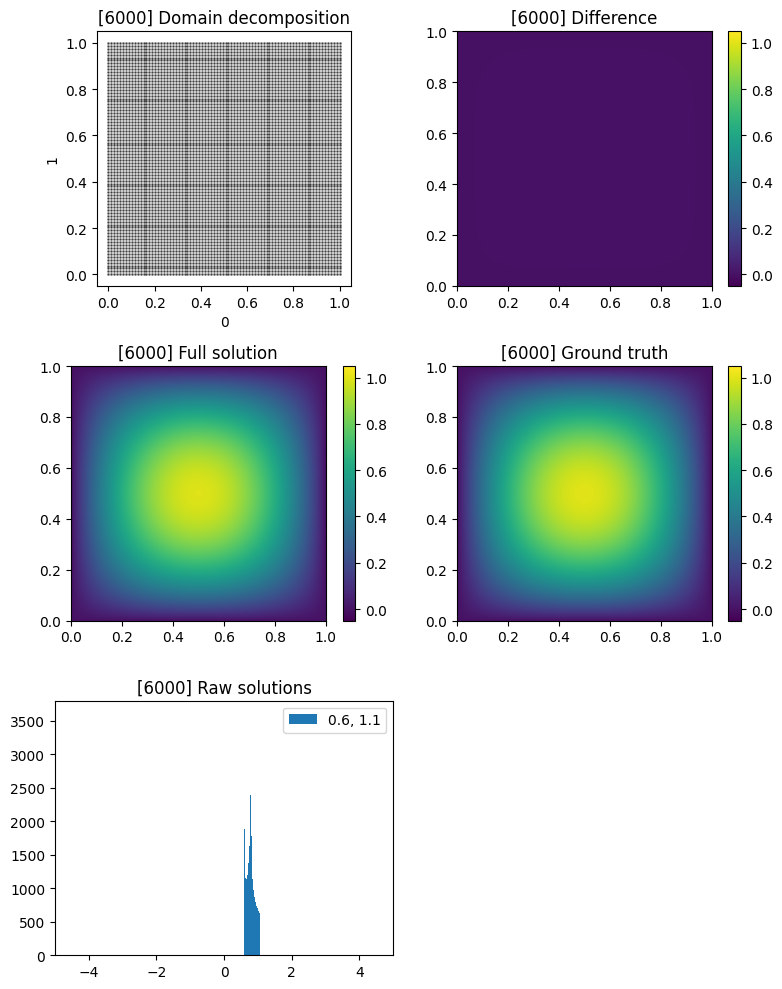

[INFO] 2026-03-12 22:55:53 - [i: 6200/15000] loss: 0.0014 rate: 3.8 elapsed: 0.47 hr pinn_3x64
[INFO] 2026-03-12 22:56:59 - [i: 6400/15000] loss: 0.0013 rate: 3.6 elapsed: 0.49 hr pinn_3x64
[INFO] 2026-03-12 23:11:00 - [i: 6600/15000] loss: 0.0012 rate: 3.6 elapsed: 0.72 hr pinn_3x64
[INFO] 2026-03-12 23:11:56 - [i: 6800/15000] loss: 0.0012 rate: 4.3 elapsed: 0.74 hr pinn_3x64
[INFO] 2026-03-12 23:12:52 - [i: 7000/15000] loss: 0.0013 rate: 4.3 elapsed: 0.75 hr pinn_3x64


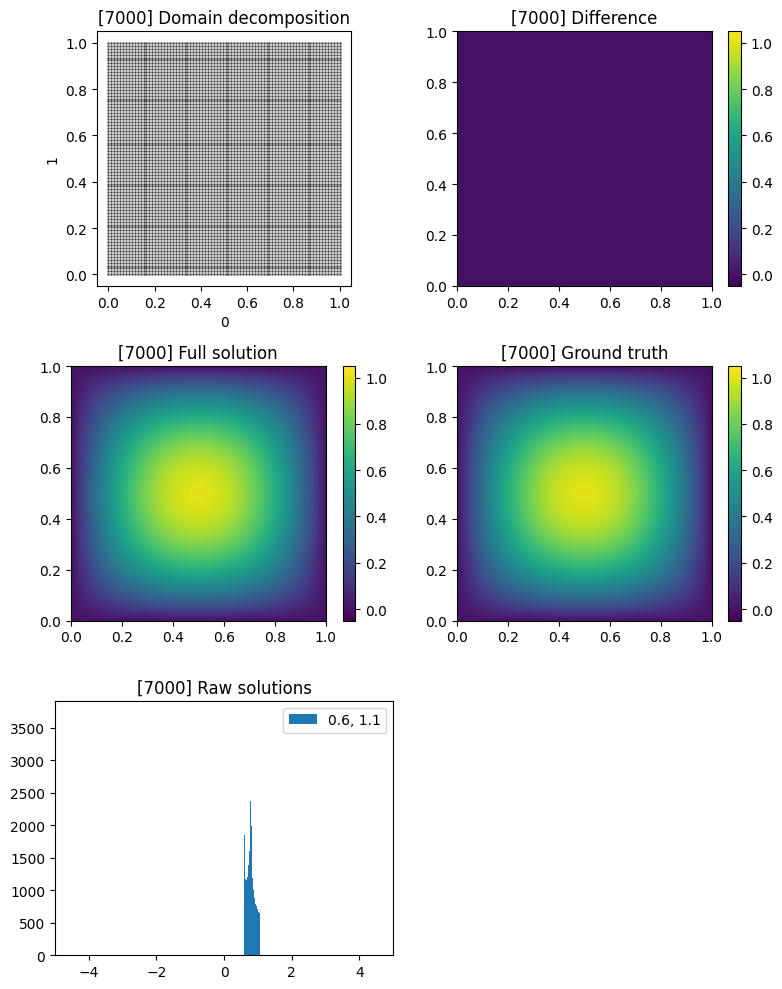

[INFO] 2026-03-12 23:13:52 - [i: 7200/15000] loss: 0.0011 rate: 4.1 elapsed: 0.77 hr pinn_3x64
[INFO] 2026-03-12 23:14:52 - [i: 7400/15000] loss: 0.0013 rate: 4.1 elapsed: 0.78 hr pinn_3x64
[INFO] 2026-03-12 23:15:45 - [i: 7600/15000] loss: 0.0010 rate: 4.5 elapsed: 0.80 hr pinn_3x64
[INFO] 2026-03-12 23:16:45 - [i: 7800/15000] loss: 0.0010 rate: 4.1 elapsed: 0.82 hr pinn_3x64
[INFO] 2026-03-12 23:17:47 - [i: 8000/15000] loss: 0.0011 rate: 3.8 elapsed: 0.83 hr pinn_3x64


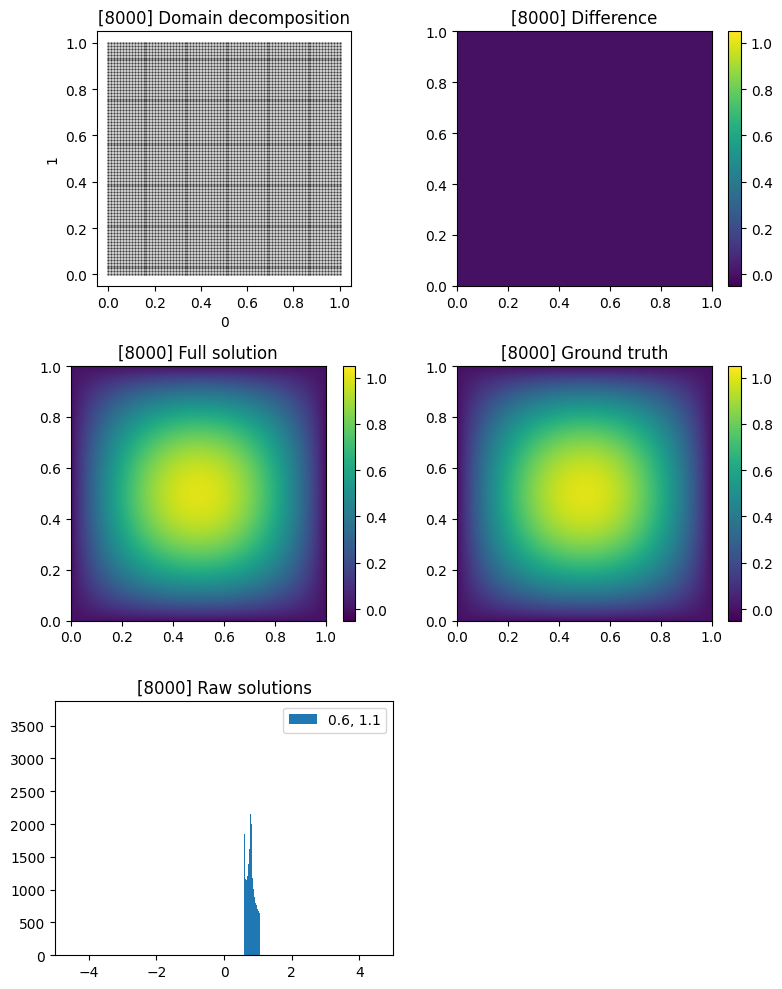

[INFO] 2026-03-12 23:18:46 - [i: 8200/15000] loss: 0.0009 rate: 4.1 elapsed: 0.85 hr pinn_3x64
[INFO] 2026-03-12 23:19:42 - [i: 8400/15000] loss: 0.0076 rate: 4.2 elapsed: 0.86 hr pinn_3x64
[INFO] 2026-03-12 23:20:35 - [i: 8600/15000] loss: 0.0014 rate: 4.6 elapsed: 0.88 hr pinn_3x64
[INFO] 2026-03-12 23:21:38 - [i: 8800/15000] loss: 0.0175 rate: 3.9 elapsed: 0.90 hr pinn_3x64
[INFO] 2026-03-12 23:22:36 - [i: 9000/15000] loss: 0.0008 rate: 4.1 elapsed: 0.91 hr pinn_3x64


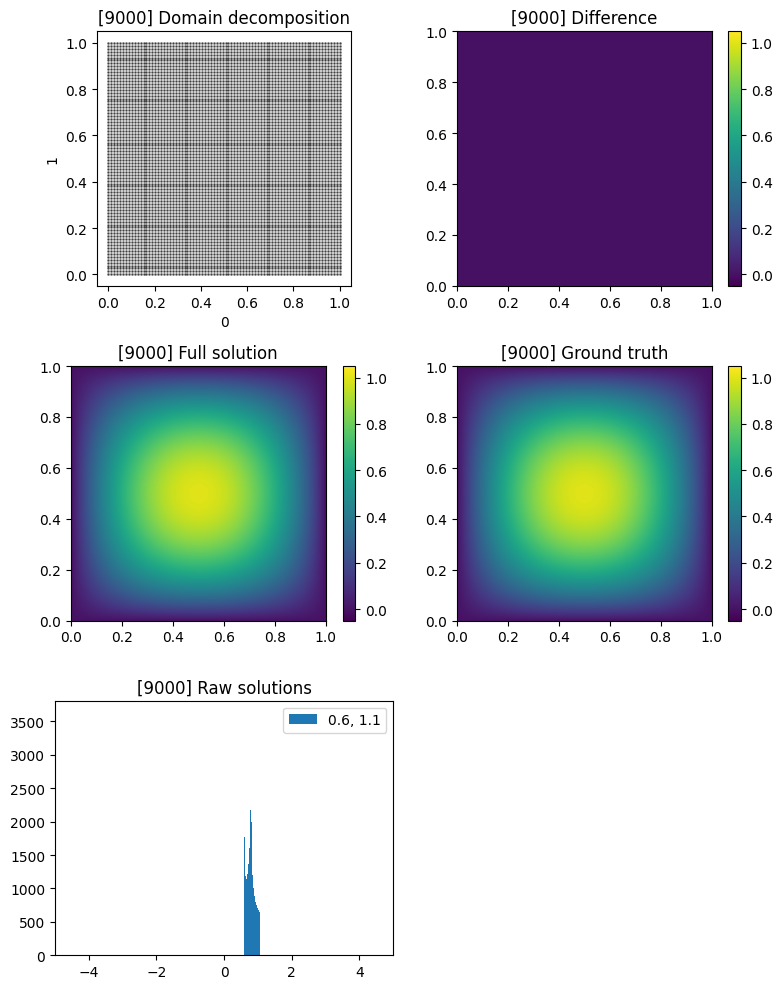

[INFO] 2026-03-12 23:23:31 - [i: 9200/15000] loss: 0.0015 rate: 4.4 elapsed: 0.93 hr pinn_3x64
[INFO] 2026-03-12 23:24:27 - [i: 9400/15000] loss: 0.0008 rate: 4.4 elapsed: 0.94 hr pinn_3x64
[INFO] 2026-03-12 23:25:25 - [i: 9600/15000] loss: 0.0016 rate: 4.2 elapsed: 0.96 hr pinn_3x64
[INFO] 2026-03-12 23:26:26 - [i: 9800/15000] loss: 0.0018 rate: 3.8 elapsed: 0.98 hr pinn_3x64
[INFO] 2026-03-12 23:27:20 - [i: 10000/15000] loss: 0.0011 rate: 4.5 elapsed: 0.99 hr pinn_3x64


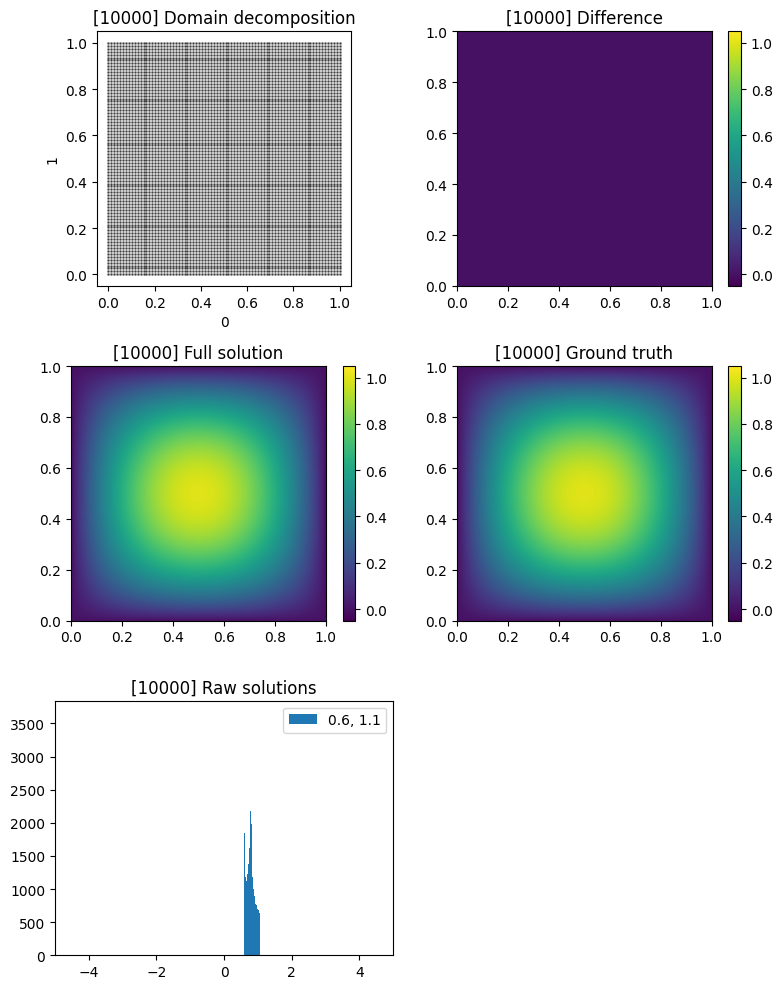

[INFO] 2026-03-12 23:28:16 - [i: 10200/15000] loss: 0.0008 rate: 4.4 elapsed: 1.01 hr pinn_3x64
[INFO] 2026-03-12 23:29:10 - [i: 10400/15000] loss: 0.0007 rate: 4.4 elapsed: 1.02 hr pinn_3x64
[INFO] 2026-03-12 23:30:07 - [i: 10600/15000] loss: 0.0007 rate: 4.3 elapsed: 1.04 hr pinn_3x64
[INFO] 2026-03-12 23:31:03 - [i: 10800/15000] loss: 0.0007 rate: 4.3 elapsed: 1.05 hr pinn_3x64
[INFO] 2026-03-12 23:32:00 - [i: 11000/15000] loss: 0.0006 rate: 4.3 elapsed: 1.07 hr pinn_3x64


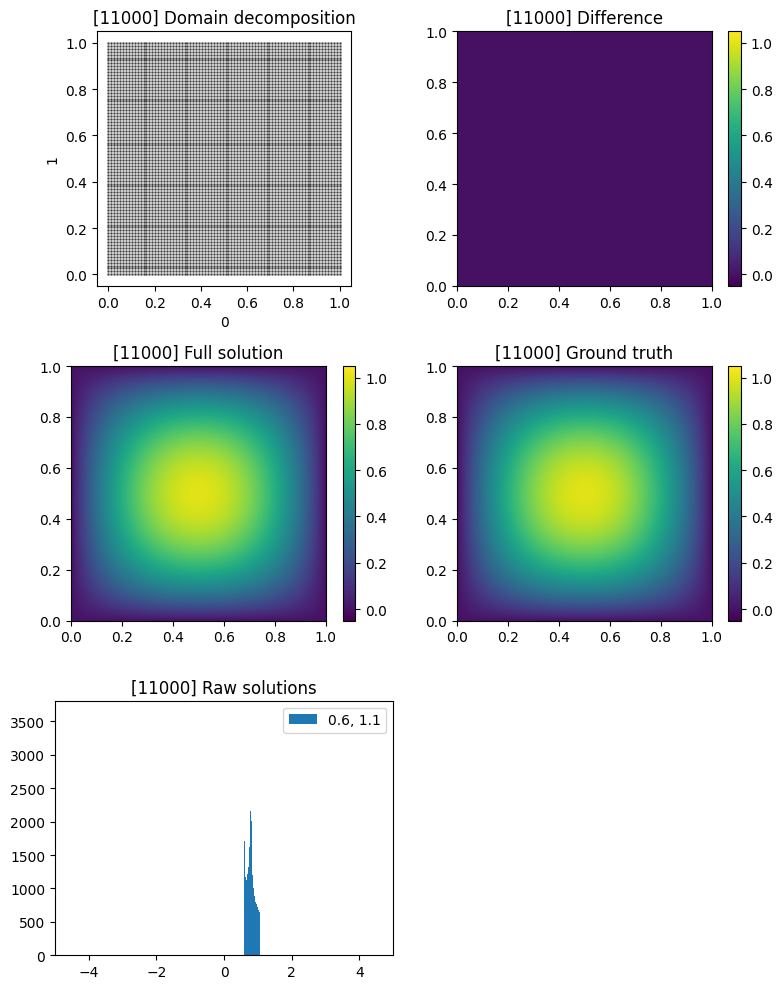

[INFO] 2026-03-12 23:32:56 - [i: 11200/15000] loss: 0.0006 rate: 4.3 elapsed: 1.09 hr pinn_3x64
[INFO] 2026-03-12 23:33:50 - [i: 11400/15000] loss: 0.0008 rate: 4.5 elapsed: 1.10 hr pinn_3x64
[INFO] 2026-03-12 23:34:45 - [i: 11600/15000] loss: 0.0006 rate: 4.4 elapsed: 1.12 hr pinn_3x64
[INFO] 2026-03-12 23:35:43 - [i: 11800/15000] loss: 0.0037 rate: 4.0 elapsed: 1.13 hr pinn_3x64
[INFO] 2026-03-12 23:36:37 - [i: 12000/15000] loss: 0.0006 rate: 4.6 elapsed: 1.15 hr pinn_3x64


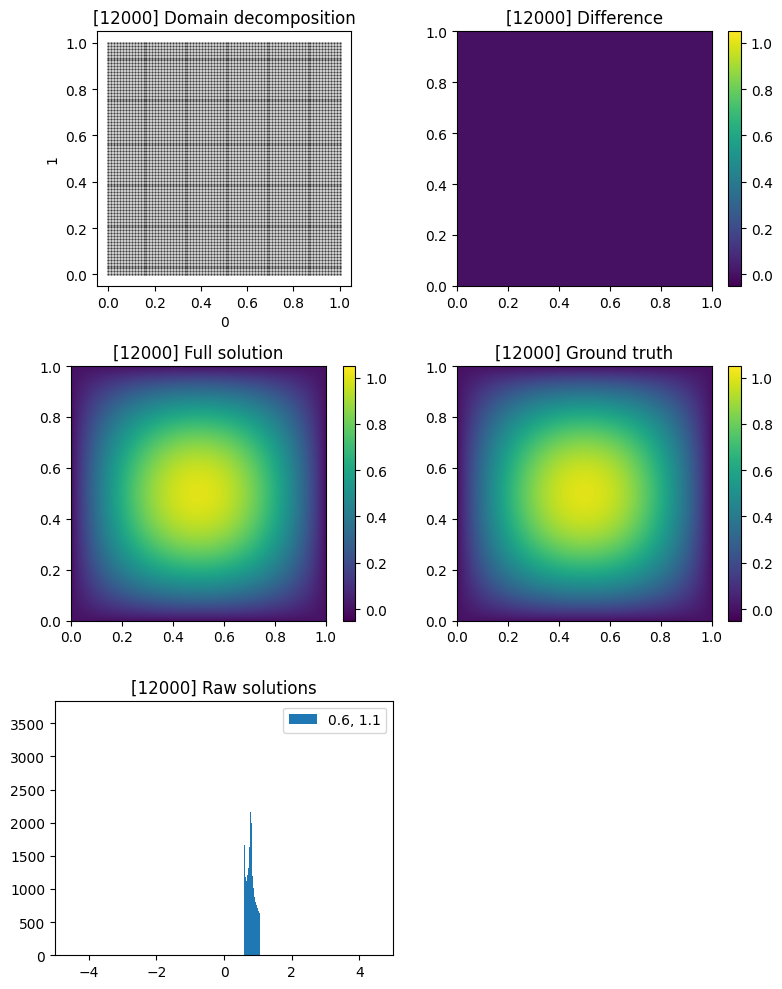

[INFO] 2026-03-12 23:37:35 - [i: 12200/15000] loss: 0.0006 rate: 4.2 elapsed: 1.16 hr pinn_3x64
[INFO] 2026-03-12 23:38:35 - [i: 12400/15000] loss: 0.0100 rate: 4.0 elapsed: 1.18 hr pinn_3x64
[INFO] 2026-03-12 23:39:36 - [i: 12600/15000] loss: 0.0006 rate: 4.0 elapsed: 1.20 hr pinn_3x64
[INFO] 2026-03-12 23:40:35 - [i: 12800/15000] loss: 0.0008 rate: 4.1 elapsed: 1.21 hr pinn_3x64
[INFO] 2026-03-12 23:41:33 - [i: 13000/15000] loss: 0.0005 rate: 4.1 elapsed: 1.23 hr pinn_3x64


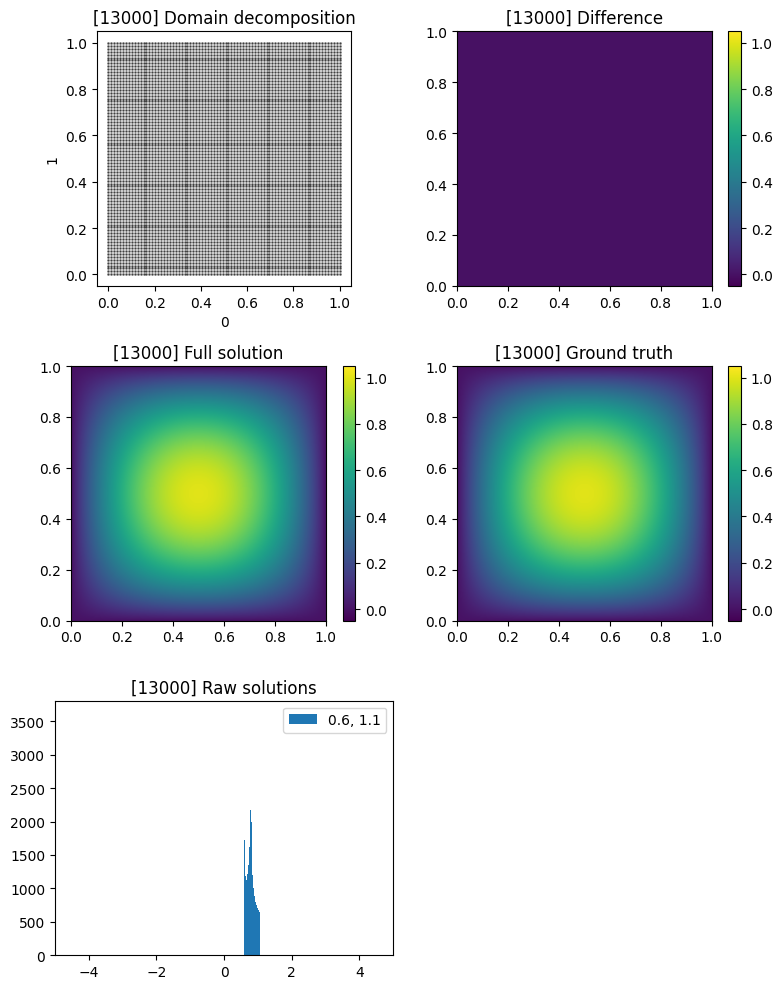

[INFO] 2026-03-12 23:42:32 - [i: 13200/15000] loss: 0.0008 rate: 4.2 elapsed: 1.25 hr pinn_3x64
[INFO] 2026-03-12 23:43:34 - [i: 13400/15000] loss: 0.0005 rate: 3.9 elapsed: 1.26 hr pinn_3x64
[INFO] 2026-03-12 23:44:41 - [i: 13600/15000] loss: 0.0005 rate: 3.6 elapsed: 1.28 hr pinn_3x64
[INFO] 2026-03-12 23:45:48 - [i: 13800/15000] loss: 0.0005 rate: 3.6 elapsed: 1.30 hr pinn_3x64
[INFO] 2026-03-12 23:46:55 - [i: 14000/15000] loss: 0.0007 rate: 3.6 elapsed: 1.32 hr pinn_3x64


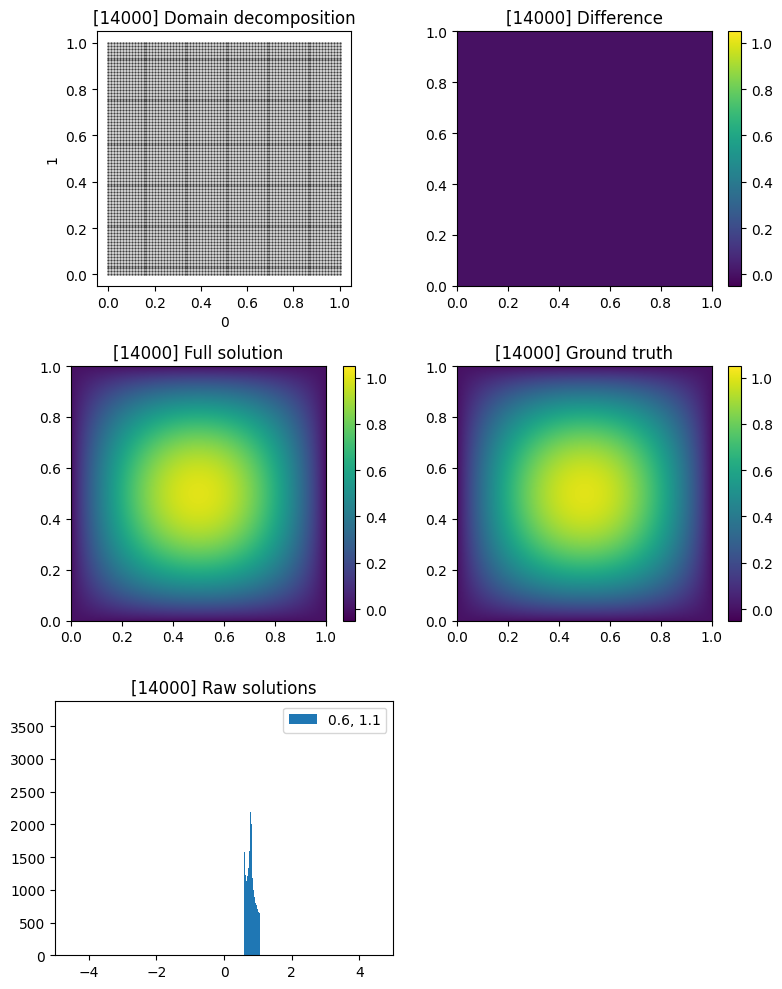

[INFO] 2026-03-12 23:48:01 - [i: 14200/15000] loss: 0.0005 rate: 3.7 elapsed: 1.34 hr pinn_3x64
[INFO] 2026-03-12 23:49:10 - [i: 14400/15000] loss: 0.0052 rate: 3.4 elapsed: 1.36 hr pinn_3x64
[INFO] 2026-03-12 23:50:19 - [i: 14600/15000] loss: 0.0008 rate: 3.5 elapsed: 1.37 hr pinn_3x64
[INFO] 2026-03-12 23:51:26 - [i: 14800/15000] loss: 0.0024 rate: 3.6 elapsed: 1.39 hr pinn_3x64
[INFO] 2026-03-12 23:52:29 - [i: 15000/15000] loss: 0.0004 rate: 3.8 elapsed: 1.41 hr pinn_3x64


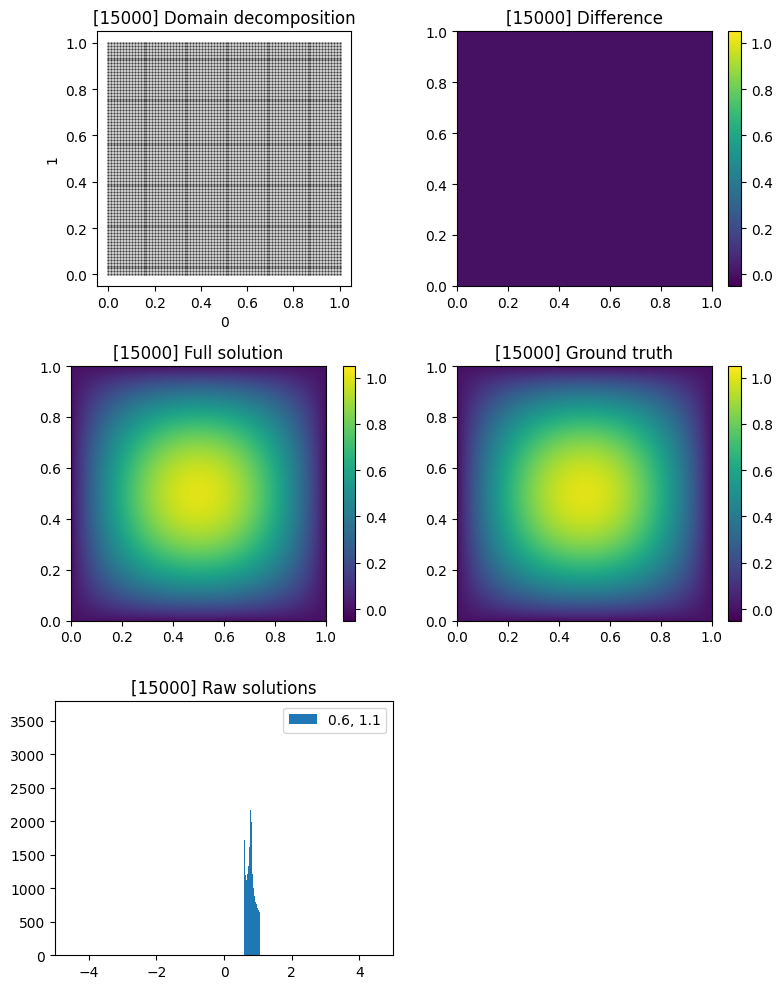

[INFO] 2026-03-12 23:52:30 - [i: 15000/15000] Training complete


{'static': {'domain': {'xd': 2,
   'xmin': Array([0., 0.], dtype=float32),
   'xmax': Array([1., 1.], dtype=float32)},
  'problem': {'dims': (1, 2), 'sigma': 0.2},
  'decomposition': {'m': np.int64(1),
   'xd': 2,
   'subdomain': {'params': [Array([[-0.5, -0.5]], dtype=float32),
     Array([[1.5, 1.5]], dtype=float32),
     Array([[1., 1.]], dtype=float32),
     Array([[1., 1.]], dtype=float32),
     Array([[0.]], dtype=float32),
     Array([[0., 1.]], dtype=float32)],
    'pou': Array([[0.]], dtype=float32)},
   'xmins0': array([[0., 0.]]),
   'xmaxs0': array([[1., 1.]])}},
 'trainable': {'network': {'subdomain': {'layers': [(Array([[[ 0.65645796,  0.14267386],
              [-0.8324695 , -0.8537229 ],
              [-0.3879982 , -0.29697746],
              [ 0.44479534,  0.02414667],
              [-0.14369226,  0.36672878],
              [ 0.3475695 ,  0.6087972 ],
              [-0.8341263 , -0.9102956 ],
              [-0.24103297, -0.7274778 ],
              [ 0.864399  ,  0.7351

In [2]:
# PINN baseline (single global network)

decomposition_init_kwargs = dict(
    subdomain_xs=[np.array([0.5]), np.array([0.5])],
    subdomain_ws=[np.array([2.0]), np.array([2.0])],
    unnorm=(0.0,1.0),
)

c = Constants(
    run="pinn_3x64",

    domain=domain,
    domain_init_kwargs=domain_init_kwargs,

    problem=problem,
    problem_init_kwargs=problem_init_kwargs,

    decomposition=RectangularDecompositionND,
    decomposition_init_kwargs=decomposition_init_kwargs,

    network=FCN,
    network_init_kwargs=dict(layer_sizes=[2,64,64,64,1]),

    ns=((80,80),),
    n_test=(350,350),

    n_steps=15000,
    summary_freq=200,
    test_freq=200,
)

trainer = FBPINNTrainer(c)
trainer.train()